# Per-Host Benchmark Metrics

In [1]:
from provenance_explorer.registry.registry_all import WORK, CACHE_ROOT
from pathlib import Path
import pickle
import json
import pandas as pd
import numpy as np

pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:.6g}')

from provenance_explorer.analysis.provenance_capture.correctness import (
    compute_gaps_per_host,
    extract_timing_errors,
    compute_timespan_per_host,
)
from provenance_explorer.analysis.system_scale.volumetrics import (
    compute_volumetrics,
)
from provenance_explorer.analysis.system_scale.workload_variability import (
    fit_hmm_select_k,
)
from provenance_explorer.analysis.activity_realism.activity_evolution.evolution_metrics import (
    compute_activity_evolution_metrics,
)

## Data Loading

In [2]:
path_counts = CACHE_ROOT / "events_per_host_plot"
file_counts = "events_per_host.parquet"

path_timing = CACHE_ROOT / "timestamp_disorder_plot"
file_timing = "timestamp_disorder.json"

path_object_lookup = CACHE_ROOT / "object_lookups"
file_object_lookup = lambda ds, subds: path_object_lookup / f"{ds}_{subds}_meta.pkl"

path_evolution = CACHE_ROOT / "activity_evolution_plot"
file_evolution = "activity_evolution.parquet"

def _load_pkl(path: Path):
    with open(path, 'rb') as fh:
        return pickle.load(fh)

def _load_json(path: Path):
    with open(path) as fh:
        return json.load(fh)

def _load_parquet(path: Path):
    return pd.read_parquet(path)

ds_subds = [
    ("e3", "cadets"),
    ("e3", "clearscope"),
    ("e3", "fivedirections"),
    ("e3", "theia"),
    ("e3", "trace"),
    ("e5", "cadets"),
    ("e5", "clearscope"),
    ("e5", "fivedirections"),
    ("e5", "marple"),
    ("e5", "theia"),
    ("e5", "trace"),
    ("optc", "aia_51_75"),
    ("optc", "aia_201_225"),
    ("optc", "aia_501_525"),
    ("optc", "aia_951_975"),
]

## Compute Metrics

In [3]:
all_rows = []
bic_curves = {}

for ds, subds in ds_subds:
    print(f"Processing {ds}/{subds}...")

    event_counts = _load_parquet(path_counts / ds / subds / file_counts)
    timing_errors = _load_json(path_timing / ds / subds / file_timing)
    evolution_ledger = _load_parquet(path_evolution / ds / subds / file_evolution)

    # 1. Gaps
    df_gaps = compute_gaps_per_host(event_counts)

    # 2. Timing errors
    df_timing = extract_timing_errors(timing_errors)

    # 3. Volumetrics (events/s, infoflow/s)
    df_vol = compute_volumetrics(event_counts)

    # 4. Workload variability (GHMM + BIC)
    df_wl = fit_hmm_select_k(event_counts, k_max=15, n_restarts=5, bin_size_minutes=15)

    # BIC curves for plotting
    for _, row in df_wl.iterrows():
        bic_curves[(ds, subds, row["host_id"])] = row["bic_curve"]

    # Drop bic_curve column before merge (not tabular)
    df_wl_tab = df_wl.drop(columns=["bic_curve"])

    # 5. Timespan (first-to-last bin per host)
    df_timespan = compute_timespan_per_host(event_counts)

    # 6. Activity evolution (unique normalised cmdlines + saturation AUC)
    df_evo = compute_activity_evolution_metrics(evolution_ledger, ds, subds)

    # Merge all per-host frames
    df = df_gaps.merge(df_timing, on="host_id", how="outer")
    df = df.merge(df_vol, on="host_id", how="outer")
    df = df.merge(df_wl_tab, on="host_id", how="outer")
    df = df.merge(df_timespan, on="host_id", how="outer")
    df = df.merge(df_evo, on="host_id", how="outer")

    # Add dataset identifiers
    df.insert(0, "dataset", ds)
    df.insert(1, "sub_dataset", subds)

    all_rows.append(df)
    print(f"{len(df)} host(s) done.")

metrics_table = pd.concat(all_rows, ignore_index=True)
print(f"\nTotal: {len(metrics_table)} rows")

Processing e3/cadets...
1 host(s) done.
Processing e3/clearscope...


Fitting a model with 44 free scalar parameters with only 31 data points will result in a degenerate solution.
Fitting a model with 44 free scalar parameters with only 31 data points will result in a degenerate solution.
Fitting a model with 44 free scalar parameters with only 31 data points will result in a degenerate solution.


1 host(s) done.
Processing e3/fivedirections...


Fitting a model with 44 free scalar parameters with only 31 data points will result in a degenerate solution.
Fitting a model with 44 free scalar parameters with only 31 data points will result in a degenerate solution.
Fitting a model with 63 free scalar parameters with only 31 data points will result in a degenerate solution.
Fitting a model with 63 free scalar parameters with only 31 data points will result in a degenerate solution.
Fitting a model with 63 free scalar parameters with only 31 data points will result in a degenerate solution.
Fitting a model with 63 free scalar parameters with only 31 data points will result in a degenerate solution.
Fitting a model with 63 free scalar parameters with only 31 data points will result in a degenerate solution.
Fitting a model with 84 free scalar parameters with only 31 data points will result in a degenerate solution.
Fitting a model with 84 free scalar parameters with only 31 data points will result in a degenerate solution.
Fitting a 

3 host(s) done.
Processing e3/theia...
1 host(s) done.
Processing e3/trace...


Fitting a model with 44 free scalar parameters with only 30 data points will result in a degenerate solution.
Fitting a model with 44 free scalar parameters with only 30 data points will result in a degenerate solution.
Fitting a model with 44 free scalar parameters with only 30 data points will result in a degenerate solution.
Fitting a model with 44 free scalar parameters with only 30 data points will result in a degenerate solution.
Fitting a model with 44 free scalar parameters with only 30 data points will result in a degenerate solution.
Fitting a model with 63 free scalar parameters with only 30 data points will result in a degenerate solution.
Fitting a model with 63 free scalar parameters with only 30 data points will result in a degenerate solution.
Fitting a model with 63 free scalar parameters with only 30 data points will result in a degenerate solution.
Fitting a model with 63 free scalar parameters with only 30 data points will result in a degenerate solution.
Fitting a 

2 host(s) done.
Processing e5/cadets...
3 host(s) done.
Processing e5/clearscope...
3 host(s) done.
Processing e5/fivedirections...


Fitting a model with 324 free scalar parameters with only 316 data points will result in a degenerate solution.
Fitting a model with 324 free scalar parameters with only 316 data points will result in a degenerate solution.
Fitting a model with 324 free scalar parameters with only 316 data points will result in a degenerate solution.
Fitting a model with 324 free scalar parameters with only 316 data points will result in a degenerate solution.
Fitting a model with 324 free scalar parameters with only 316 data points will result in a degenerate solution.
Fitting a model with 363 free scalar parameters with only 316 data points will result in a degenerate solution.
Fitting a model with 363 free scalar parameters with only 316 data points will result in a degenerate solution.
Fitting a model with 363 free scalar parameters with only 316 data points will result in a degenerate solution.
Fitting a model with 363 free scalar parameters with only 316 data points will result in a degenerate so

4 host(s) done.
Processing e5/marple...
1 host(s) done.
Processing e5/theia...
3 host(s) done.
Processing e5/trace...
3 host(s) done.
Processing optc/aia_51_75...
25 host(s) done.
Processing optc/aia_201_225...
25 host(s) done.
Processing optc/aia_501_525...
25 host(s) done.
Processing optc/aia_951_975...
25 host(s) done.

Total: 125 rows


## Full Results Table

In [4]:
display_cols = [
    "dataset", "sub_dataset", "host_id",
    # Timespan
    "timespan_days",
    # Provenance Capture
    "gap_pct",
    "timing_error_rate", "timing_mean_error_s", "timing_std_error_s", "timing_max_error_s",
    # System Scale - Volumetrics
    "avg_events_per_s", "std_events_per_s",
    "avg_infoflow_per_s", "std_infoflow_per_s",
    # System Scale - Workload Variability
    "best_k",
    # Activity Realism - Activity Evolution
    "n_unique_normalized_cmdlines", "saturation_auc_unit",
]

metrics_table[display_cols]

,dataset,sub_dataset,host_id,timespan_days,gap_pct,timing_error_rate,timing_mean_error_s,timing_std_error_s,timing_max_error_s,avg_events_per_s,std_events_per_s,avg_infoflow_per_s,std_infoflow_per_s,best_k,n_unique_normalized_cmdlines,saturation_auc_unit
0,e3,cadets,83C8ED1F-5045-DBCD-B39F-918F0DF4F851,10.98,1.1698,5.85235e-06,0.0100413,0.000641531,0.0200003,44.09,52.86,25.39,26.06,4,485,0.767902
1,e3,clearscope,5957F7A8-2EAB-D99C-459A-408A1F427D29,11.31,7.4563,0.047097,0.0041845,0.0174322,4.234,265.8,292.37,242.64,262.54,5,41,0.63279
2,e3,fivedirections,47923ED7-29D4-4E65-ABA2-F70A4E74DCCD,0.31,0,0.0832907,5.71831,204.605,26668.1,166.13,204.51,47.43,59.1,1,122,0.925683
3,e3,fivedirections,D2842312-8456-4C8E-ADD6-E2295D0939D3,8.57,0,0.0692275,43.334,3092.81,735283,346.62,482.92,93.52,108.87,5,251,0.802612
4,e3,fivedirections,eb742520-0326-4e78-9768-0cb079cd0f93,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,162,0.825907
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,optc,aia_951_975,SysClient0971.systemia.com,6.75,8.8386,0.161792,1.90558,5.28984,648.352,54.36,26.37,45,21.44,3,176,0.87462
121,optc,aia_951_975,SysClient0972.systemia.com,6.75,2.3124,0.158343,2.04314,5.94608,506.234,53.8,26.5,44.41,21.4,3,174,0.890166
122,optc,aia_951_975,SysClient0973.systemia.com,6.75,2.3124,0.160325,2.13791,9.49319,1281.16,53,25.95,44.03,21.05,3,168,0.887008
123,optc,aia_951_975,SysClient0974.systemia.com,6.75,2.3124,0.159365,1.97323,5.52688,486.847,54.47,26.33,44.57,21.05,3,195,0.815772


In [5]:
metrics_table[display_cols].to_excel("display_table.xlsx")
metrics_table.to_csv("full_table.csv", index=False)

## BIC Curves sanity check

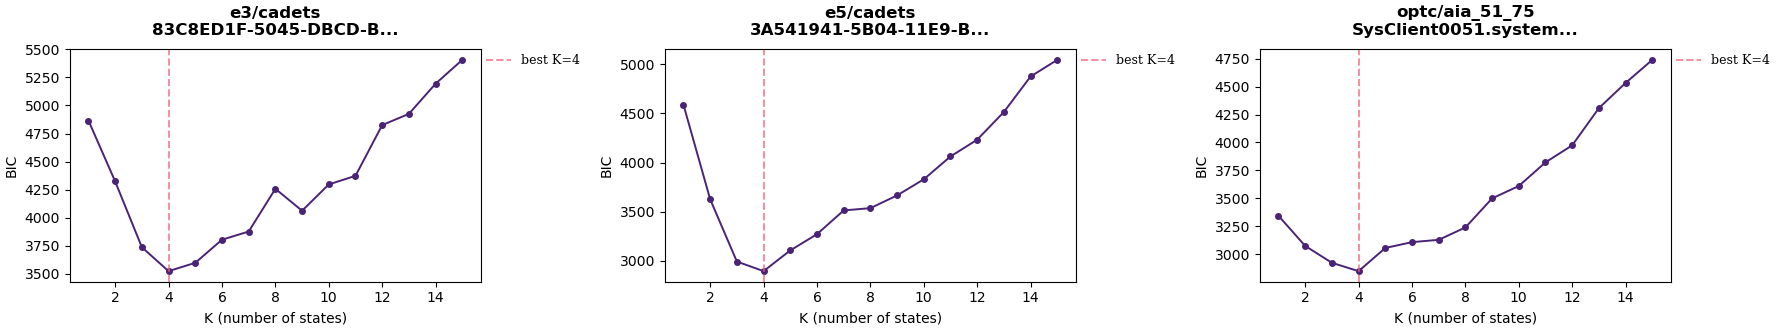

In [6]:
import matplotlib.pyplot as plt
from provenance_explorer.analysis.system_scale.workload_variability import (
    plot_bic_curve,
)

# Pick first host from each dataset family for illustration
examples = {}
for (ds, subds, host), curve in bic_curves.items():
    if ds not in examples and curve:
        examples[ds] = (ds, subds, host, curve)

fig, axes = plt.subplots(1, len(examples), figsize=(6 * len(examples), 3.5))
if len(examples) == 1:
    axes = [axes]

for ax, (ds, (ds_, subds, host, curve)) in zip(axes, examples.items()):
    plot_bic_curve(curve, title=f"{ds_}/{subds}\n{host[:20]}...", ax=ax)

plt.tight_layout()
plt.show()

## State Sequence Sanity Check

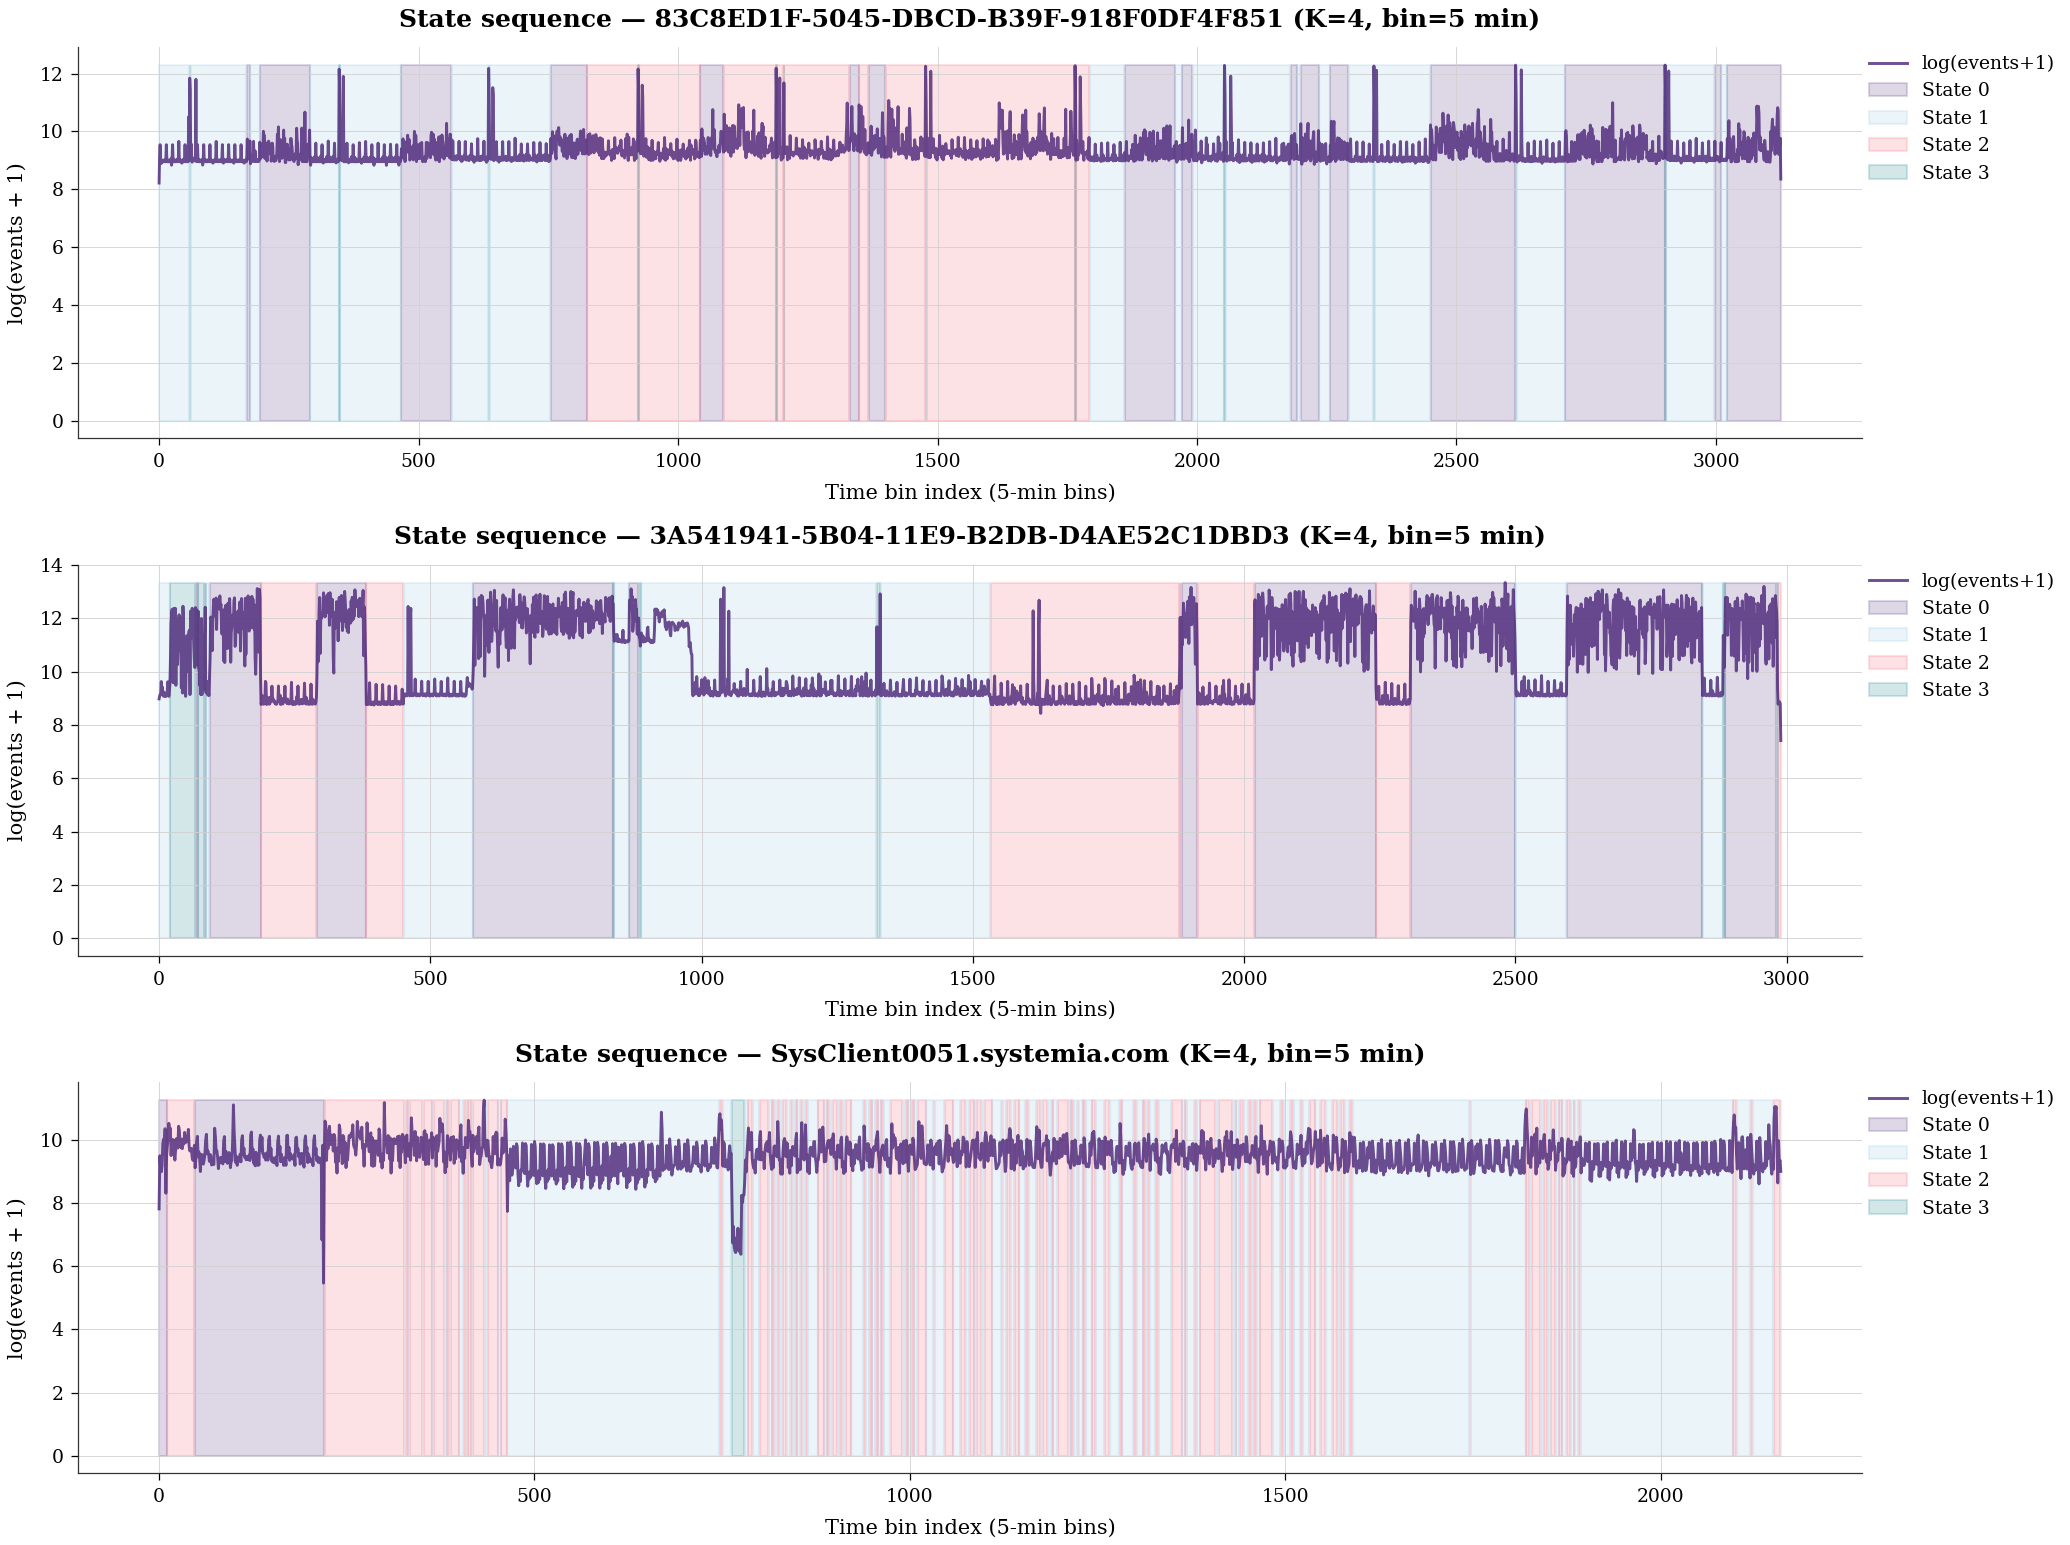

In [7]:
from provenance_explorer.analysis.system_scale.workload_variability import (
    plot_state_sequence,
)

fig, axes = plt.subplots(len(examples), 1, figsize=(14, 3.5 * len(examples)))
if len(examples) == 1:
    axes = [axes]

for ax, (ds, (ds_, subds, host, curve)) in zip(axes, examples.items()):
    event_counts = _load_parquet(path_counts / ds_ / subds / file_counts)
    best_k = min(curve, key=lambda x: x[1])[0]
    plot_state_sequence(event_counts, host, best_k, ax=ax)

plt.tight_layout()
plt.show()

## Aggregation Exploration

In [8]:
# For multi-host sub-datasets, show coefficient of variation for key metrics
key_metrics = [
    "gap_pct", "avg_events_per_s", "avg_infoflow_per_s", "best_k",
    "timespan_days", "n_unique_normalized_cmdlines", "saturation_auc_unit",
]

multi_host = (
    metrics_table
    .groupby(["dataset", "sub_dataset"])
    .filter(lambda g: len(g) > 1)
)

if len(multi_host) > 0:
    agg = (
        multi_host
        .groupby(["dataset", "sub_dataset"])[key_metrics]
        .agg(["mean", "std", "count"])
    )
    print("Multi-host sub-datasets — mean and std of key metrics:")
    display(agg)
else:
    print("All sub-datasets have a single host.")

Multi-host sub-datasets — mean and std of key metrics:


gap_pct                avg_events_per_s               avg_infoflow_per_s                best_k                timespan_days                  n_unique_normalized_cmdlines               saturation_auc_unit                 
                          mean      std count             mean     std count               mean     std count    mean      std count          mean        std count                         mean     std count                mean        std count
dataset sub_dataset                                                                                                                                                                                                                                
e3      fivedirections       0        0     2          256.375 127.626     2             70.475 32.5906     2       3  2.82843     2          4.44     5.8407     2                      178.333 66.0328     3            0.851401  0.0653763     3
        trace                0        0     2          861.115 30.3985     2             617.81 195.869     2       3  2.82843     2          5.48    7.32563     2                          319 217.789     2            0.811352  0.0235657     2
e5      cadets               0        0     3           443.58 178.445     3              280.2 162.473     3 3.66667  0.57735     3         10.38          0     3                          513 16.0935     3            0.835763  0.0234006     3
        clearscope       2.194     2.78     3          287.463   41.87     3            183.243 23.4549     3 4.66667  0.57735     3       10.6433     3.9433     3                           95      14     3             0.87373 0.00806601     3
        fivedirections 10.1167  17.0354     4          1196.13 118.476     4            484.085 48.3993     4    3.75 0.957427     4         8.735    3.64693     4                          253 85.5609     4              0.8058   0.183902     4
        theia          8.30823  8.77819     3          461.503  33.553     3            415.713 18.0483     3       4        1     3         10.36          0     3                      1600.67 927.335     3             0.76559  0.0531411     3
        trace                0        0     3          1739.01  39.786     3            1380.46  34.681     3 3.33333  0.57735     3         10.35          0     3                      717.667  175.42     3            0.821907  0.0878609     3
optc    aia_201_225    9.80998  6.99209    25          53.1776 4.08209    25             43.366 2.24984    25    3.44 0.650641    25          8.79          0    25                        187.8 8.99537    25            0.913653  0.0300774    25
        aia_501_525     3.8642  3.45643    25          50.3564 3.34543    25            42.2176 2.09358    25    3.08 0.759386    25         6.762 0.00408248    25                       172.52  11.091    25            0.921524  0.0267134    25
        aia_51_75      14.0071 0.465346    25          51.1972 3.10847    25             42.426 2.00955    25    3.36  0.81035    25           8.8          0    25                        182.6 7.78353    25            0.851034  0.0244783    25
        aia_951_975    3.02768  2.53492    25          50.3908 3.31026    25             42.238 2.07014    25    3.52 0.822598    25        6.7504      0.002    25                       174.72 5.40463    25            0.895449  0.0222981    25